# Testing Data Retrieval and Database Building from WQP
Using WQP's webservice APIs

In [1]:
# %pip -q install pandas

In [18]:
import requests
import pandas as pd
from io import StringIO

url = "https://www.waterqualitydata.us/data/Result/search"
bbox = "-88.7,41.3,-84.4,46.4"  # lake michigan rough bounding box

params = [
    # ("countrycode", "LE"),
    ("bBox", bbox),
    ("dataProfile", "resultPhysChem"),
    ("providers", "NWIS"),
    ("providers", "STORET"),
    ("mimeType", "csv"),
    ("zip", "no"),
    ("startDateLo", "01-01-2022"),
    ("startDateHi", "12-31-2022"),
]

r = requests.get(url, params=params, timeout=180)
print("STATUS:", r.status_code)
print("URL:", r.url)
print("Warning:", r.headers.get("Warning"))
print("BODY preview:", r.text[:300])

r.raise_for_status()
df = pd.read_csv(StringIO(r.text))
df.head()


STATUS: 200
URL: https://www.waterqualitydata.us/data/Result/search?bBox=-88.7%2C41.3%2C-84.4%2C46.4&dataProfile=resultPhysChem&providers=NWIS&providers=STORET&mimeType=csv&zip=no&startDateLo=01-01-2022&startDateHi=12-31-2022
BODY preview: OrganizationIdentifier,OrganizationFormalName,ActivityIdentifier,ActivityTypeCode,ActivityMediaName,ActivityMediaSubdivisionName,ActivityStartDate,ActivityStartTime/Time,ActivityStartTime/TimeZoneCode,ActivityEndDate,ActivityEndTime/Time,ActivityEndTime/TimeZoneCode,ActivityRelativeDepthName,Activit


C:\Users\kcui2\AppData\Local\Temp\ipykernel_6548\3461261359.py:27: DtypeWarning: Columns (12,15,17,19,21,24,27,34,38,41,43,49,50,58,59,73,74,76,79) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(StringIO(r.text))


,OrganizationIdentifier,OrganizationFormalName,ActivityIdentifier,ActivityTypeCode,ActivityMediaName,ActivityMediaSubdivisionName,ActivityStartDate,ActivityStartTime/Time,ActivityStartTime/TimeZoneCode,ActivityEndDate,...,LaboratoryName,AnalysisStartDate,ResultLaboratoryCommentText,ResultDetectionQuantitationLimitUrl,DetectionQuantitationLimitTypeName,DetectionQuantitationLimitMeasure/MeasureValue,DetectionQuantitationLimitMeasure/MeasureUnitCode,LabSamplePreparationUrl,LastUpdated,ProviderName
0,WIDNR_WQX,Wisconsin Department of Natural Resources,WIDNR_WQX-354246555,Field Msr/Obs,Water,NaN,2022-08-11,NaN,NaN,2023-08-07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-12-01T05:09:07,STORET
1,WIDNR_WQX,Wisconsin Department of Natural Resources,WIDNR_WQX-327067919,Field Msr/Obs,Water,NaN,2022-05-13,10:15:00,CDT,2022-05-13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-12-07T05:54:26,STORET
2,WIDNR_WQX,Wisconsin Department of Natural Resources,WIDNR_WQX-332770694,Field Msr/Obs,Water,NaN,2022-05-28,15:30:00,CDT,2022-05-28,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-01-13T05:08:12,STORET
3,WIDNR_WQX,Wisconsin Department of Natural Resources,WIDNR_WQX-329632595,Field Msr/Obs,Water,NaN,2022-05-12,14:30:00,CDT,2022-05-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-12-23T04:51:48,STORET
4,WIDNR_WQX,Wisconsin Department of Natural Resources,WIDNR_WQX-354233617,Field Msr/Obs,Water,NaN,2022-08-11,NaN,NaN,2023-08-07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-11-29T05:13:33,STORET


In [19]:
df.shape

(662129, 81)

## Core Columns for Trend Analysis

### Time Axis (Mandatory)
- `ActivityStartDate`
- `ActivityStartTime/Time`
- `ActivityEndDate`
- `ActivityEndTime/Time`

### Location Axis (Mandatory)
- `MonitoringLocationIdentifier`

### Location Context
- `ActivityDepthHeightMeasure/MeasureValue`
- `ActivityMediaName`

### Measurement Axis (Mandatory)
- `CharacteristicName`
- `ResultMeasureValue`
- `ResultMeasure/MeasureUnitCode`

---

## Quality Control Columns
- `ResultStatusIdentifier`
- `MeasureQualifierCode`
- `DetectionQuantitationLimitMeasure/MeasureValue`
- `ResultDetectionConditionText`

---

## Optional but Useful Columns
- `ProjectIdentifier`
- `ResultAnalyticalMethod/MethodName`
- `DataProvider`
- `ActivityDepthHeightMeasure/MeasureUnitCode`


Other potential columns:
- `ResultSampleFractionText`
- `ResultStatusIdentifier`
- `ResultAnalyticalMethod/MethodIdentifier`
- `ResultAnalyticalMethod/MethodIdentifierContext`
- `ResultAnalyticalMethod/MethodName`

- `AnalysisStartDate`
- `LastUpdated`

In [22]:
# filter only necessary columns
columns_to_keep = [
    "ActivityStartDate",
    "ActivityStartTime/Time",
    "ActivityEndDate",
    "ActivityEndTime/Time",
    "MonitoringLocationIdentifier",
    "ActivityDepthHeightMeasure/MeasureValue",
    "ActivityMediaName",
    "CharacteristicName",
    "ResultMeasureValue",
    "ResultMeasure/MeasureUnitCode",
    "ResultStatusIdentifier",
    "MeasureQualifierCode",
    "DetectionQuantitationLimitMeasure/MeasureValue",
    "ResultDetectionConditionText",
    "ProjectIdentifier",
    "ResultAnalyticalMethod/MethodName",
    "ProviderName",
    "ActivityDepthHeightMeasure/MeasureUnitCode",
]

df_target = df[columns_to_keep]
df_target.head(10), df_target.shape


(  ActivityStartDate ActivityStartTime/Time ActivityEndDate  \
 0        2022-08-11                    NaN      2023-08-07   
 1        2022-05-13               10:15:00      2022-05-13   
 2        2022-05-28               15:30:00      2022-05-28   
 3        2022-05-12               14:30:00      2022-05-12   
 4        2022-08-11                    NaN      2023-08-07   
 5        2022-05-24               15:30:00      2022-05-24   
 6        2022-06-22               11:30:00             NaN   
 7        2022-09-19               22:52:09             NaN   
 8        2022-06-10               10:19:00             NaN   
 9        2022-05-25               16:00:00      2022-10-27   
 
   ActivityEndTime/Time MonitoringLocationIdentifier  \
 0             13:00:00           WIDNR_WQX-10047844   
 1             23:59:00           WIDNR_WQX-10051137   
 2             23:59:00           WIDNR_WQX-10012500   
 3             23:59:00             WIDNR_WQX-603121   
 4             13:00:00  

In [24]:
%pip install matplotlib

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 859.3 kB/s eta 0:00:10
   -- ------------------------------------- 0.5/8.3 MB 859.3 kB/s eta 0:00:10
   --- ------------------------------------ 0.8/8.3 MB 877.1 kB/s eta 0:00:09
   ----- ---------------------------------- 1.0/8.3 MB 890.4 kB/s eta 0:00:09
   ----- ---------------------------------- 1.0/8.3 MB 890.4 kB/s eta 0:00:09
   ------ --------------------------------- 1.3/8.3 MB 849.9 kB/s eta 0:00:09
   ------ --------------------------------- 1.3/8.3 MB 849.9 kB/s eta 0:00:09
   ------ --------------------------------- 1.3/8.3 MB 849.9 kB/s eta 0:00:09
   ------- -------------------------------- 1.6/8.3 MB 717.7 kB/s eta 0:00:10
   ------- -------------------------------- 1.6/8.3 MB 717.7 kB/s eta 0:00:10
   ------- --

num rows after cleaning: 604714
unique characteristics: 528
Plotting characteristic: pH | unit: mV


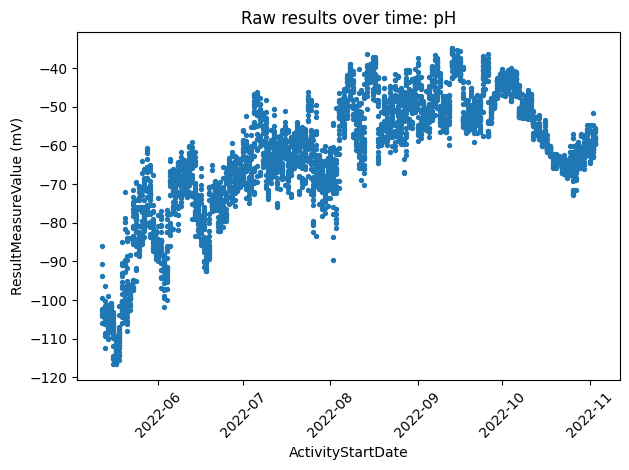

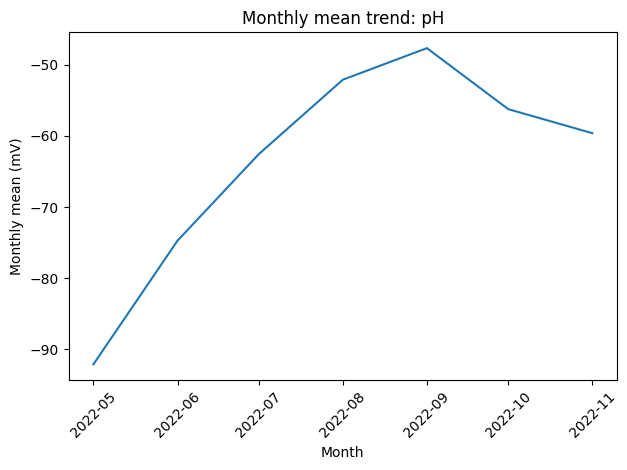

C:\Users\kcui2\AppData\Local\Temp\ipykernel_6548\881363518.py:75: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=False)


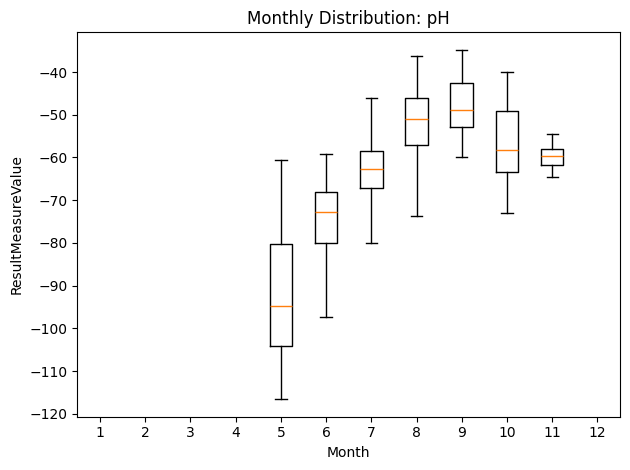

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

data = df_target.copy()

# basic cleaning
data["ActivityStartDate"] = pd.to_datetime(data["ActivityStartDate"], errors="coerce")

# ensure measurements are numeric values
data["ResultMeasureValue"] = pd.to_numeric(data["ResultMeasureValue"], errors="coerce")

# (optional) only keep data labeled as "accepted," note that this removes majority of data
# data = data[data["ResultStatusIdentifier"].astype(str).str.lower().eq("accepted")]

# drop rows missing critical fields
data = data.dropna(subset=["ActivityStartDate", "CharacteristicName", "ResultMeasureValue"])

print("num rows after cleaning:", len(data))
print("unique characteristics:", data["CharacteristicName"].nunique())

# pick a characteristic
# char = data["CharacteristicName"].value_counts().index[2]  # change the index for a common measurement
# or
char = 'pH'  # hardcode

dchar = data[data["CharacteristicName"] == char].copy()

# multiple units exist --> pick the most common unit to avoid unit-mixing in plots
if "ResultMeasure/MeasureUnitCode" in dchar.columns:
    unit = dchar["ResultMeasure/MeasureUnitCode"].value_counts().index[0]
    dchar = dchar[dchar["ResultMeasure/MeasureUnitCode"] == unit]
else:
    unit = None

print("Plotting characteristic:", char, "| unit:", unit)

# plot A: raw time series (all points)
plt.figure()
plt.scatter(dchar["ActivityStartDate"], dchar["ResultMeasureValue"], s=8)
plt.xlabel("ActivityStartDate")
plt.ylabel("ResultMeasureValue" + (f" ({unit})" if unit else ""))
plt.title(f"Raw results over time: {char}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# plot B: monthly average trend
monthly = (
    dchar.set_index("ActivityStartDate")["ResultMeasureValue"]
         .resample("MS")
         .mean()
         .dropna()
)

plt.figure()
plt.plot(monthly.index, monthly.values)
plt.xlabel("Month")
plt.ylabel("Monthly mean" + (f" ({unit})" if unit else ""))
plt.title(f"Monthly mean trend: {char}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# plot C: monthly boxplots (distribution by month), can be yearly when we have more data
dchar["Month"] = dchar["ActivityStartDate"].dt.month

months = list(range(1, 13))

box_data = [
    dchar.loc[dchar["Month"] == m, "ResultMeasureValue"].dropna().values
    for m in months
]

plt.figure()
plt.boxplot(box_data, labels=months, showfliers=False)
plt.xlabel("Month")
plt.ylabel("ResultMeasureValue")
plt.title(f"Monthly Distribution: {char}")
plt.tight_layout()
plt.show()


In [ ]:
# visualizations for multiple characteristics
def plot_wqp_characteristic_trends(
    df: pd.DataFrame,
    characteristics,
    date_col: str = "ActivityStartDate",
    char_col: str = "CharacteristicName",
    value_col: str = "ResultMeasureValue",
    unit_col: str = "ResultMeasure/MeasureUnitCode",
    only_accepted: bool = False,
    status_col: str = "ResultStatusIdentifier",
    choose_unit: str = "most_common",   # "most_common" or a specific unit string
    showfliers: bool = False,
    point_size: int = 8
):
    """
    For each characteristic in `characteristics`, plots:
      A) raw scatter over time
      B) monthly mean trend
      C) monthly boxplots (distribution by month)

    Notes:
      - Drops rows with missing date/characteristic/value
      - Coerces date/value types
      - Optionally filters to accepted results
      - If multiple units exist, can pick the most common unit to avoid mixing
    """
    # Normalize characteristics input
    if isinstance(characteristics, str):
        characteristics = [characteristics]

    data = df.copy()

    # Basic cleaning
    data[date_col] = pd.to_datetime(data[date_col], errors="coerce")
    data[value_col] = pd.to_numeric(data[value_col], errors="coerce")

    if only_accepted and status_col in data.columns:
        data = data[data[status_col].astype(str).str.lower().eq("accepted")]

    # Drop rows missing critical fields
    data = data.dropna(subset=[date_col, char_col, value_col])

    print("num rows after cleaning:", len(data))
    print("unique characteristics:", data[char_col].nunique())

    for char in characteristics:
        dchar = data[data[char_col] == char].copy()

        if dchar.empty:
            print(f"Skipping '{char}' (no rows after filtering).")
            continue

        # Unit handling
        unit = None
        if unit_col in dchar.columns:
            if choose_unit == "most_common":
                unit = dchar[unit_col].dropna().value_counts().index[0] if dchar[unit_col].notna().any() else None
                if unit is not None:
                    dchar = dchar[dchar[unit_col] == unit]
            else: 
                unit = choose_unit
                dchar = dchar[dchar[unit_col] == unit]

        if dchar.empty:
            print(f"Skipping '{char}' (no rows after unit filter).")
            continue

        print("Plotting characteristic:", char, "| unit:", unit)

        # ---- Plot A: raw time series (scatter) ----
        plt.figure(figsize=(4, 3))
        plt.scatter(dchar[date_col], dchar[value_col], s=point_size)
        plt.xlabel(date_col)
        plt.ylabel(value_col + (f" ({unit})" if unit else ""))
        plt.title(f"Raw results over time: {char}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # ---- Plot B: monthly mean trend ----
        monthly = (
            dchar.set_index(date_col)[value_col]
                .resample("MS")
                .mean()
                .dropna()
        )

        plt.figure(figsize=(4, 3))
        plt.plot(monthly.index, monthly.values)
        plt.xlabel("Month")
        plt.ylabel("Monthly mean" + (f" ({unit})" if unit else ""))
        plt.title(f"Monthly mean trend: {char}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # ---- Plot C: monthly boxplots ----
        dchar["Month"] = dchar[date_col].dt.month
        months = list(range(1, 13))

        box_data = [
            dchar.loc[dchar["Month"] == m, value_col].dropna().values
            for m in months
        ]

        plt.figure(figsize=(4, 3))
        plt.boxplot(box_data, labels=months, showfliers=showfliers)
        plt.xlabel("Month")
        plt.ylabel(value_col + (f" ({unit})" if unit else ""))
        plt.title(f"Monthly distribution: {char}")
        plt.tight_layout()
        plt.show()


num rows after cleaning: 604714
unique characteristics: 528
Plotting characteristic: pH | unit: mV


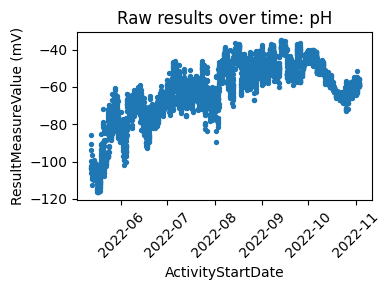

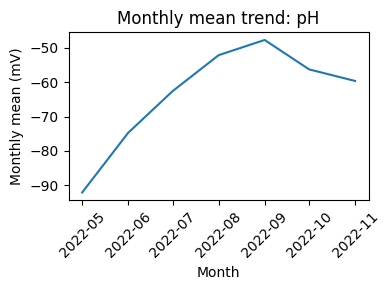

C:\Users\kcui2\AppData\Local\Temp\ipykernel_6548\2269672727.py:107: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


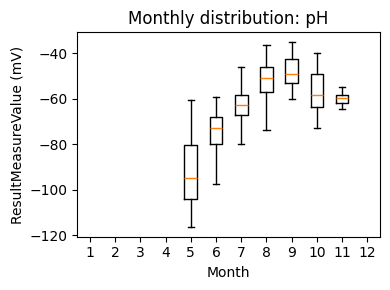

Plotting characteristic: Temperature | unit: deg C


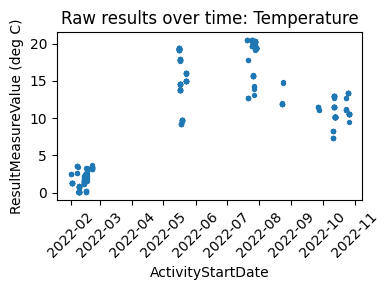

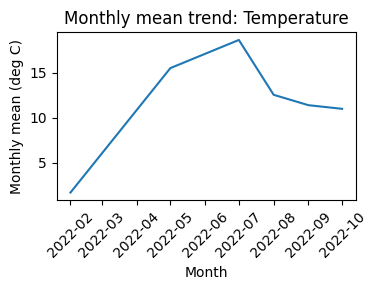

C:\Users\kcui2\AppData\Local\Temp\ipykernel_6548\2269672727.py:107: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


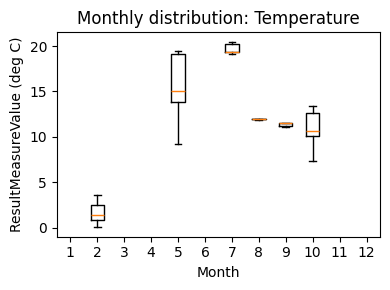

Skipping 'water' (no rows after filtering).
Plotting characteristic: Dissolved oxygen (DO) | unit: mg/L


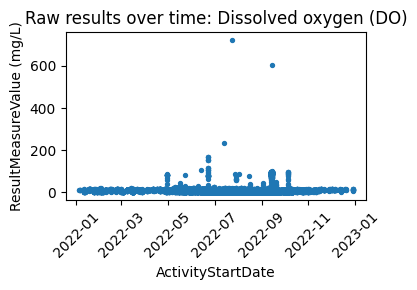

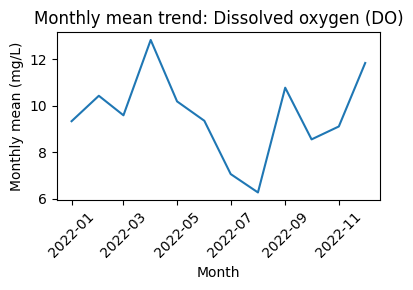

C:\Users\kcui2\AppData\Local\Temp\ipykernel_6548\2269672727.py:107: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


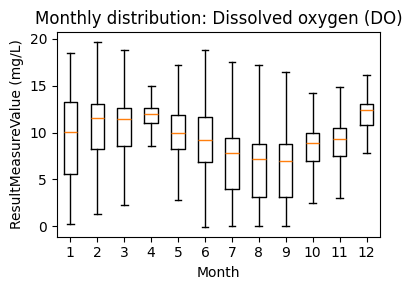

Plotting characteristic: Phosphorus | unit: mg/L


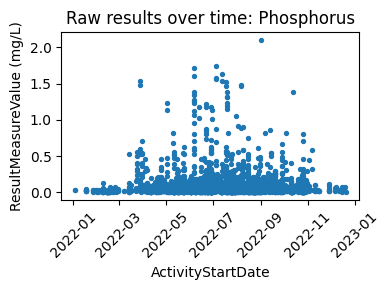

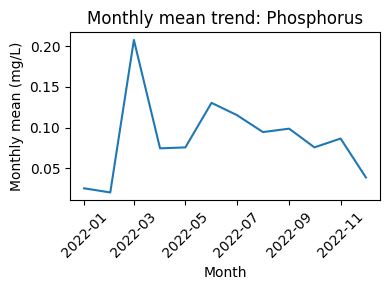

C:\Users\kcui2\AppData\Local\Temp\ipykernel_6548\2269672727.py:107: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


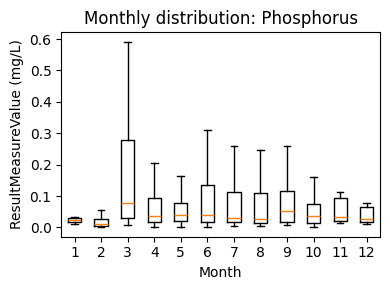

In [42]:
chars = ["pH", "Temperature", "water", "Dissolved oxygen (DO)", "Phosphorus"]
plot_wqp_characteristic_trends(df_target, chars)
